In [1]:
# 修改日期后，从此处运行全部单元格
DATA_START = "2021-01-01"
DATA_END = "2026-03-18"
SYMBOLS = ["510300.SS", "513100.SS", "518880.SS"]
NAMES = ["沪深300", "纳指100", "黄金"]
REBALANCE_MONTHS = 3
MOMENTUM_MONTHS = 3
VOL_DAYS = 20
INITIAL_CAPITAL = 100_000.0
ANNUAL_DAYS = 252
WEIGHT_TOL = 1e-6


# 三种资产配置方法
三种方案均在首个交易日建仓，此后每三个自然月的首个可交易日开盘调仓；期间持股数固定，实际权重随价格漂移。
- 等权：每项 1/3。
- 对角协方差风险平价：过去 20 个日收益的标准差为 σ，权重为 (1/σ) / Σ(1/σ)。因为风险贡献占比为 w²σ² / Σ(w²σ²)，所以三项相等。仅调仓时恢复风险平价。
- RAM 动量：RAM = 过去3个月收益 / 过去20日日收益标准差；只对正 RAM 按数值比例分配，非正 RAM 为0。无正 RAM 时现金权重100%，现金收益率为0。

信号仅使用交易日前的数据；成交按当日开盘价，收盘估值。为精确比较配置权重，使用碎股、无费用/滑点/税费，无追加资金、无杠杆。它是权重研究模型，不使用公共 SimBroker 的整数股订单规则。
下载起点自动向前延伸用于预热；收益统计仅覆盖 DATA_START 到 DATA_END。
每次校验三只ETF与现金四项权重之和；全部空仓时ETF之和为0。每季度重新判断，季度内不会因RAM变化而调仓。


In [2]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import yfinance as yf
from IPython.display import display

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "q3").is_dir() and (p / "pyproject.toml").exists())
cache = root / "q3" / "data"
figures = root / "q3" / "figures"
cache.mkdir(exist_ok=True)
figures.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(cache / "yfinance"))
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
start, end = pd.Timestamp(DATA_START), pd.Timestamp(DATA_END)
if start > end:
    raise ValueError("开始日期不能晚于结束日期")
warmup_start = (start - pd.DateOffset(months=MOMENTUM_MONTHS + 2)
                - pd.Timedelta(days=VOL_DAYS * 2)).strftime("%Y-%m-%d")

def load_bars(symbol):
    path = cache / f"{symbol}_{warmup_start}_{DATA_END}_adjusted.csv"
    if path.exists():
        frame = pd.read_csv(path, index_col="Date", parse_dates=True)
    else:
        frame = yf.download(symbol, start=warmup_start,
                            end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
                            auto_adjust=True, multi_level_index=False,
                            progress=False, threads=False, timeout=30)
        if frame.empty:
            raise RuntimeError(f"{symbol} 下载失败，无有效缓存；稍后重试，其他缓存会保留")
        frame.index.name = "Date"
        frame.to_csv(path)
        time.sleep(2)
    frame.index = pd.to_datetime(frame.index).tz_localize(None)
    frame = frame.sort_index().loc[warmup_start:DATA_END, ["Open", "Close"]]
    if frame.empty or frame.index.has_duplicates:
        raise ValueError(f"{symbol} 日期为空或重复")
    if not np.isfinite(frame.to_numpy()).all() or (frame <= 0).any().any():
        raise ValueError(f"{symbol} 价格无效")
    print(symbol, len(frame), frame.index.min().date(), frame.index.max().date())
    return frame

bars = {s: load_bars(s) for s in SYMBOLS}
opens = pd.concat({s: bars[s]["Open"] for s in SYMBOLS}, axis=1).sort_index()
closes = pd.concat({s: bars[s]["Close"] for s in SYMBOLS}, axis=1).sort_index()
# 公开缺口：不填造价格，只在三者均有开收盘价时估值/交易。
complete = opens.notna().all(axis=1) & closes.notna().all(axis=1)
excluded_dates = opens.index[~complete]
print("缺少任一标的行情、剔除的日期：", excluded_dates.strftime("%Y-%m-%d").tolist())
opens, closes = opens.loc[complete], closes.loc[complete]
dates = closes.loc[DATA_START:DATA_END].index
if len(dates) < 2:
    raise ValueError("有效回测日期不足")
print("实际统计区间：", dates.min().date(), "至", dates.max().date())
print("若有内部缺口，跨缺口收益不是严格单日收益，波动率和夏普为近似。")


510300.SS 1389 2020-06-22 2026-03-18
513100.SS 1390 2020-06-22 2026-03-18
518880.SS 1389 2020-06-22 2026-03-18
缺少任一标的行情、剔除的日期： ['2025-10-24']
实际统计区间： 2021-01-04 至 2026-03-18
若有内部缺口，跨缺口收益不是严格单日收益，波动率和夏普为近似。


C:\Users\27223\AppData\Local\Temp\ipykernel_14000\65643528.py:49: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  opens = pd.concat({s: bars[s]["Open"] for s in SYMBOLS}, axis=1).sort_index()
C:\Users\27223\AppData\Local\Temp\ipykernel_14000\65643528.py:50: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  closes = pd.concat({s: bars[s]["Close"] for s in SYMBOLS}, axis=1).sort_index()


In [3]:
WEIGHT_COLUMNS = SYMBOLS + ["CASH"]

def check_weights(weights, label="weights"):
    w = np.asarray(weights, dtype=float)
    if w.shape != (len(WEIGHT_COLUMNS),) or not np.isfinite(w).all() or (w < 0).any():
        raise ValueError(f"{label}: 权重必须是四个有限非负数（含现金）")
    error = abs(w.sum() - 1.0)
    if error > WEIGHT_TOL:
        raise ValueError(f"{label}: 权重和偏差 {error} 超过 {WEIGHT_TOL}")
    return w

def ram_weights(ram):
    ram = np.asarray(ram, dtype=float)
    if ram.shape != (len(SYMBOLS),) or not np.isfinite(ram).all():
        raise ValueError("RAM必须为三个有限数值")
    positive = np.maximum(ram, 0)
    if positive.sum() == 0:
        return check_weights([0, 0, 0, 1], "全部非正RAM")
    return check_weights(np.r_[positive / positive.sum(), 0], "RAM配置")

def allocate(method, history):
    if method == "等权":
        return check_weights([1/3, 1/3, 1/3, 0])
    returns = history.pct_change(fill_method=None).dropna().tail(VOL_DAYS)
    if len(returns) != VOL_DAYS:
        raise ValueError("波动率预热不足")
    sigma = returns.std(ddof=1).to_numpy()
    if not np.isfinite(sigma).all() or (sigma <= 0).any():
        raise ValueError("波动率必须为有限正数")
    if method == "风险平价":
        inverse_vol = 1 / sigma
        w = check_weights(np.r_[inverse_vol / inverse_vol.sum(), 0])
        risk_contributions = (w[:3] * sigma) ** 2
        np.testing.assert_allclose(risk_contributions / risk_contributions.sum(),
                                   np.ones(3) / 3, atol=1e-10, rtol=0)
        return w
    if method == "RAM动量":
        anchor = history.index[-1] - pd.DateOffset(months=MOMENTUM_MONTHS)
        past = history.loc[:anchor]
        if past.empty:
            raise ValueError("动量预热不足")
        momentum = history.iloc[-1] / past.iloc[-1] - 1
        return ram_weights(momentum.to_numpy() / sigma)
    raise ValueError(method)

def simulate(method):
    shares = np.zeros(3)
    cash = INITIAL_CAPITAL
    records, actual_weights, targets, audit = [], [], [], []
    previous_bucket = None
    base_month = start.year * 12 + start.month
    for date in dates:
        bucket = (date.year * 12 + date.month - base_month) // REBALANCE_MONTHS
        open_price = opens.loc[date].to_numpy()
        close_price = closes.loc[date].to_numpy()
        if previous_bucket != bucket:
            history = closes.loc[closes.index < date]
            if history.empty:
                raise ValueError("需要回测开始前的数据")
            w = allocate(method, history)
            equity_open = float(cash + shares @ open_price)
            shares = equity_open * w[:3] / open_price
            cash = equity_open * w[3]
            check_weights(np.r_[shares * open_price, cash] / equity_open, "成交后权重")
            audit.append({"date": date, "signal_date": history.index[-1],
                          **dict(zip(WEIGHT_COLUMNS, w))})
            previous_bucket = bucket
        equity = float(cash + shares @ close_price)
        actual = check_weights(np.r_[shares * close_price, cash] / equity, "每日实际权重")
        records.append(equity)
        actual_weights.append(actual)
        targets.append(w.copy())
    value = pd.Series(records, index=dates, name=method)
    daily = value.pct_change()
    daily.iloc[0] = value.iloc[0] / INITIAL_CAPITAL - 1
    vol = daily.std(ddof=1) * np.sqrt(ANNUAL_DAYS)
    # 简化夏普：无风险利率为0，日均收益 / 日标准差 × sqrt(252)。
    sharpe = (daily.mean() / daily.std(ddof=1) * np.sqrt(ANNUAL_DAYS)
              if daily.std(ddof=1) > 0 else np.nan)
    peak = np.maximum.accumulate(np.r_[INITIAL_CAPITAL, value.to_numpy()])[1:]
    return {"value": value, "daily": daily,
            "weights": pd.DataFrame(actual_weights, index=dates, columns=WEIGHT_COLUMNS),
            "targets": pd.DataFrame(targets, index=dates, columns=WEIGHT_COLUMNS),
            "audit": pd.DataFrame(audit).set_index("date"),
            "metrics": {"累计收益率": value.iloc[-1] / INITIAL_CAPITAL - 1,
                        "年化波动率": vol, "最大回撤": float(-(value / peak - 1).min()),
                        "简化夏普": sharpe}}

results = {name: simulate(name) for name in ["等权", "风险平价", "RAM动量"]}
metrics = pd.DataFrame({name: r["metrics"] for name, r in results.items()}).T
display(metrics.style.format({c: "{:.3f}" if c == "简化夏普" else "{:.2%}"
                              for c in metrics.columns}))
print(metrics.to_string())


,累计收益率,年化波动率,最大回撤,简化夏普
等权,86.98%,12.41%,16.26%,1.073
风险平价,108.68%,11.80%,14.35%,1.309
RAM动量,53.85%,16.51%,24.43%,0.606


          累计收益率     年化波动率      最大回撤      简化夏普
等权     0.869765  0.124080  0.162553  1.072827
风险平价   1.086840  0.117957  0.143465  1.308644
RAM动量  0.538515  0.165061  0.244323  0.605757


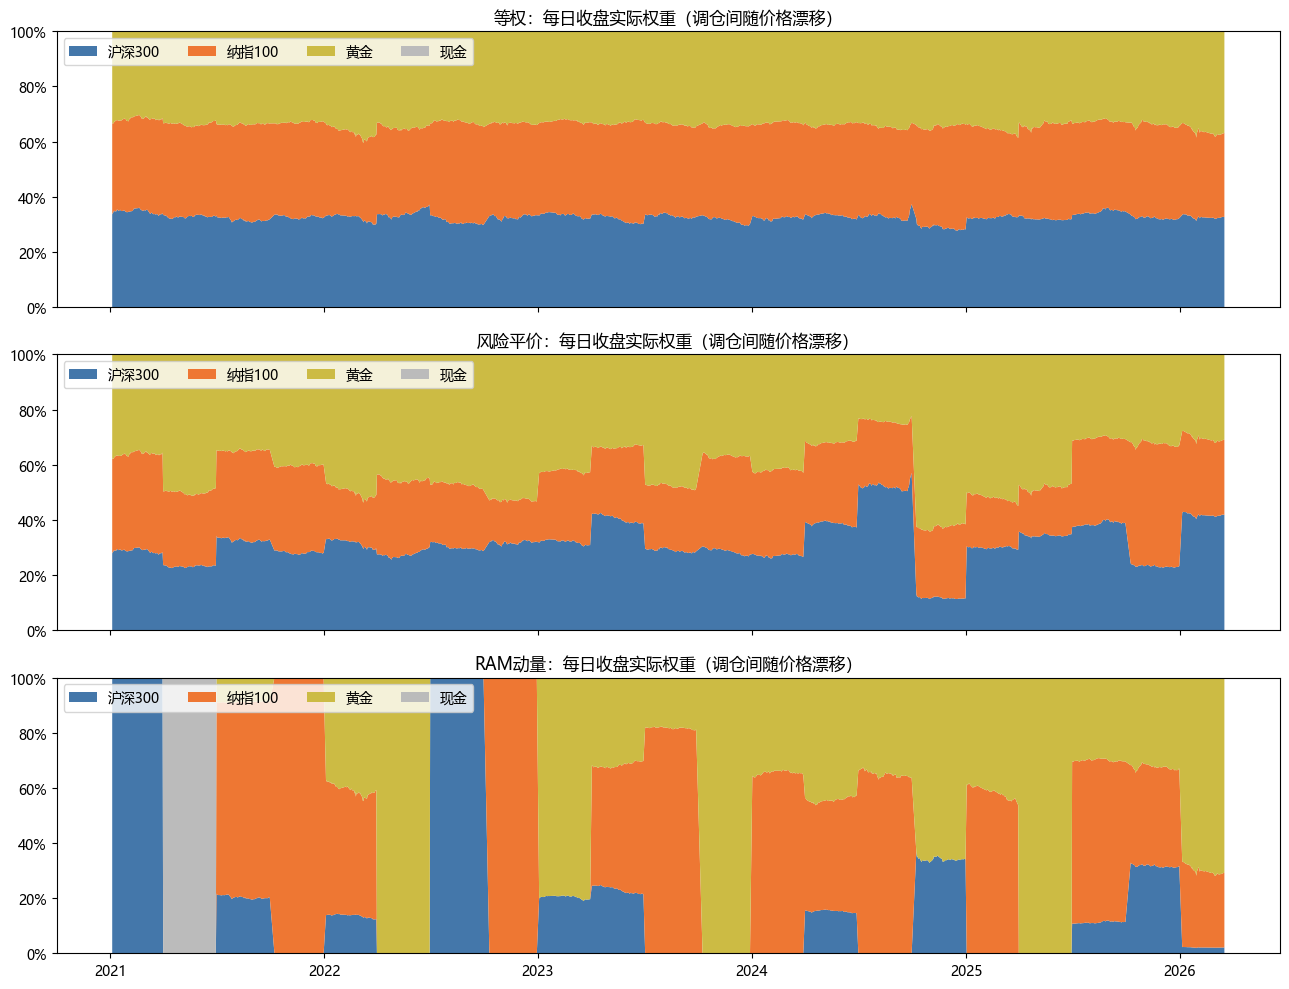

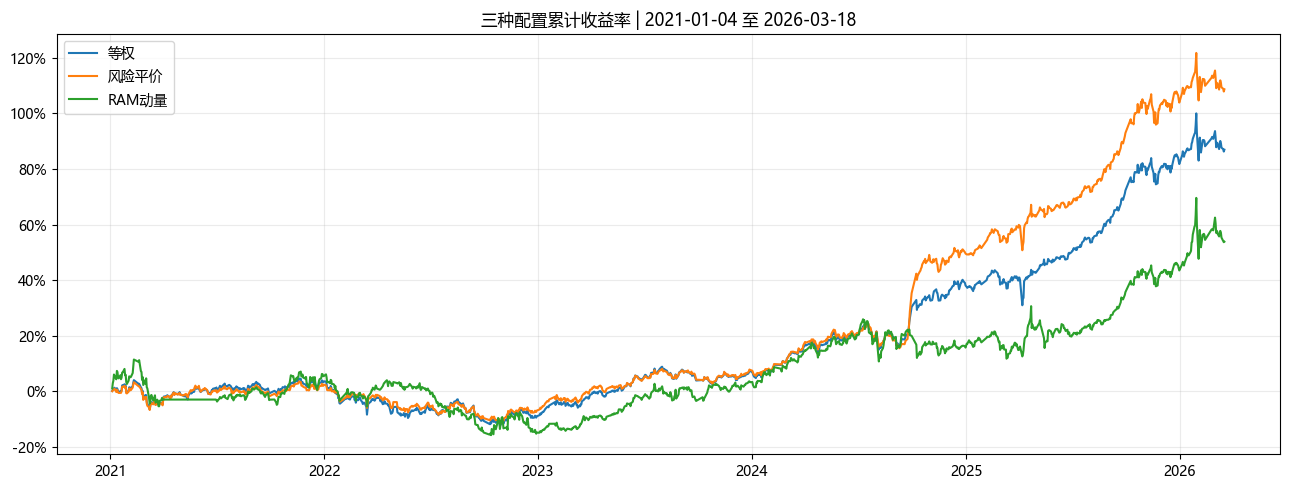

In [4]:
colors = ["#4477AA", "#EE7733", "#CCBB44", "#BBBBBB"]
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, (name, r) in zip(axes, results.items()):
    ax.stackplot(dates, r["weights"].to_numpy().T, labels=NAMES + ["现金"], colors=colors)
    ax.set_title(name + "：每日收盘实际权重（调仓间随价格漂移）")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(loc="upper left", ncol=4)
fig.tight_layout()
fig.savefig(figures / "allocation_daily_weights.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results.items():
    ax.plot(dates, r["value"] / INITIAL_CAPITAL - 1, label=name)
ax.set_title(f"三种配置累计收益率 | {dates.min():%Y-%m-%d} 至 {dates.max():%Y-%m-%d}")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(figures / "allocation_returns.png", dpi=150)
plt.show()


In [5]:
# 独立边界验证：比例分配、唯一正值、全负、全零。
np.testing.assert_allclose(ram_weights([2, 1, -1]), [2/3, 1/3, 0, 0])
np.testing.assert_allclose(ram_weights([-2, 1, -1]), [0, 1, 0, 0])
np.testing.assert_allclose(ram_weights([-2, -1, -3]), [0, 0, 0, 1])
np.testing.assert_allclose(ram_weights([0, 0, 0]), [0, 0, 0, 1])

# 审计：每日目标权重、实际权重、调仓信号时间；结果保存便于复查。
for name, r in results.items():
    for key in ["weights", "targets"]:
        errors = (r[key].sum(axis=1) - 1).abs()
        if errors.max() > WEIGHT_TOL:
            raise AssertionError(f"{name} {key} 权重和异常")
    if not (r["audit"]["signal_date"] < r["audit"].index).all():
        raise AssertionError("使用了当日或未来信号")
    # 净值连乘与资产价值必须一致
    np.testing.assert_allclose((1 + r["daily"]).cumprod(),
                               r["value"] / INITIAL_CAPITAL, rtol=1e-10)
    print(name, "调仓次数", len(r["audit"]), "最大权重和偏差",
          (r["weights"].sum(axis=1)-1).abs().max())
    display(r["audit"].head())
    r["audit"].to_csv(figures / f"{name}_rebalance_audit.csv")
    r["weights"].to_csv(figures / f"{name}_daily_weights.csv")
metrics.to_csv(figures / "allocation_metrics.csv")
print("PASS：权重和、风险贡献、信号时序、净值核算校验通过")

ram_result = results["RAM动量"]
cash_days = int((ram_result["weights"]["CASH"] > 1 - WEIGHT_TOL).sum())
print("RAM全现金收盘日数：", cash_days)
# 若前后两天都全现金，净值必须不变；转为空仓当天可含隔夜损益。
cash_mask = ram_result["weights"]["CASH"].gt(1 - WEIGHT_TOL)
np.testing.assert_allclose(ram_result["daily"].loc[cash_mask & cash_mask.shift(fill_value=False)],
                           0, atol=1e-12)
display(ram_result["audit"])


等权 调仓次数 21 最大权重和偏差 2.220446049250313e-16


,signal_date,510300.SS,513100.SS,518880.SS,CASH
date,,,,,
2021-01-04,2020-12-31,0.333333,0.333333,0.333333,0.0
2021-04-01,2021-03-31,0.333333,0.333333,0.333333,0.0
2021-07-01,2021-06-30,0.333333,0.333333,0.333333,0.0
2021-10-08,2021-09-30,0.333333,0.333333,0.333333,0.0
2022-01-04,2021-12-31,0.333333,0.333333,0.333333,0.0


风险平价 调仓次数 21 最大权重和偏差 2.220446049250313e-16


,signal_date,510300.SS,513100.SS,518880.SS,CASH
date,,,,,
2021-01-04,2020-12-31,0.275872,0.346921,0.377207,0.0
2021-04-01,2021-03-31,0.235570,0.267957,0.496473,0.0
2021-07-01,2021-06-30,0.343902,0.311867,0.344231,0.0
2021-10-08,2021-09-30,0.287195,0.305546,0.407259,0.0
2022-01-04,2021-12-31,0.332935,0.204165,0.462899,0.0


RAM动量 调仓次数 21 最大权重和偏差 2.220446049250313e-16


,signal_date,510300.SS,513100.SS,518880.SS,CASH
date,,,,,
2021-01-04,2020-12-31,1.000000,0.000000,0.000000,0.0
2021-04-01,2021-03-31,0.000000,0.000000,0.000000,1.0
2021-07-01,2021-06-30,0.217481,0.693571,0.088948,0.0
2021-10-08,2021-09-30,0.000000,1.000000,0.000000,0.0
2022-01-04,2021-12-31,0.139379,0.490860,0.369760,0.0


PASS：权重和、风险贡献、信号时序、净值核算校验通过
RAM全现金收盘日数： 60


,signal_date,510300.SS,513100.SS,518880.SS,CASH
date,,,,,
2021-01-04,2020-12-31,1.000000,0.000000,0.000000,0.0
2021-04-01,2021-03-31,0.000000,0.000000,0.000000,1.0
2021-07-01,2021-06-30,0.217481,0.693571,0.088948,0.0
2021-10-08,2021-09-30,0.000000,1.000000,0.000000,0.0
2022-01-04,2021-12-31,0.139379,0.490860,0.369760,0.0
2022-04-01,2022-03-31,0.000000,0.000000,1.000000,0.0
2022-07-01,2022-06-30,1.000000,0.000000,0.000000,0.0
2022-10-10,2022-09-30,0.000000,1.000000,0.000000,0.0
2023-01-03,2022-12-30,0.199900,0.000000,0.800100,0.0


## 原作者的购入时机
已阅读本地课程 notebook 和 open-xquant 的 Threshold 源码。
[spec-01-equal-weight.md](https://github.com/xingwudao/xquant-learning/blob/main/q3-how-much/specs/spec-01-equal-weight.md) 配置
`Threshold(column="close", threshold=0, relationship="gt")`；
源码直接返回 `close > 0` 的布尔值，这是始终持有信号，不是均线上穿信号。
原课程 notebook 使用 `RebalanceFrequencyRule(interval_days=10)` 定期再平衡。
本实验按本题改为每3个自然月调仓；风险平价用20日波动率；动量使用3个月收益/20日波动率的RAM，按正RAM数值比例归一化，全部非正则持有现金。这里明确采用用户指定的比例分配；原规格的TopN排序与等权分配不等同于按分值比例分配。
缺口处理、成交时点及调仓周期不同，结果不能直接与原规格参考收益作等价比较。
